In [4]:
from dotenv import load_dotenv
import os
load_dotenv()
API_KEY = os.getenv('KEY')

from langchain.chat_models import init_chat_model
from IPython.display import Image, display

model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)

def display_graph(app):
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

# 1.条件路由与循环:
## 1.1条件路由回顾
在第1课中，我们学习了基本的条件边。现在深入学习更复杂的路由模式。

基本条件路由:

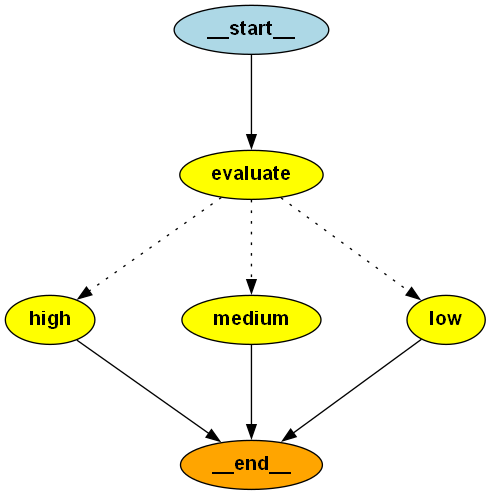


=== 执行结果 ===
最终决策: 人工审核
最终分数: 0.75

=== 测试不同分数 ===
分数 0.9: 人工审核
分数 0.7: 人工审核
分数 0.4: 人工审核


In [3]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# === 定义状态结构 ===
class State(TypedDict):
    score: float
    decision: str

# === 定义节点函数 ===
def evaluate(state: State) -> dict:
    """评估并打分"""
    return {"score": 0.75}

def route_by_score(state: State) -> Literal["high", "medium", "low"]:
    """根据分数路由"""
    score = state["score"]
    if score > 0.8:
        return "high"
    elif score > 0.5:
        return "medium"
    else:
        return "low"

def handle_high(state: State) -> dict:
    return {"decision": "自动通过"}

def handle_medium(state: State) -> dict:
    return {"decision": "人工审核"}

def handle_low(state: State) -> dict:
    return {"decision": "自动拒绝"}

# === 显示图结构的函数（需要配合前面的 display_graph 定义）===
def display_graph(app):
    """渲染并展示 LangGraph 应用的结构图"""
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

# === 构建图 ===
graph = StateGraph(State)
graph.add_node("evaluate", evaluate)
graph.add_node("high", handle_high)
graph.add_node("medium", handle_medium)
graph.add_node("low", handle_low)

graph.add_edge(START, "evaluate")
graph.add_conditional_edges(
    "evaluate",
    route_by_score,
    {
        "high": "high",
        "medium": "medium",
        "low": "low"
    }
)

for node in ["high", "medium", "low"]:
    graph.add_edge(node, END)

# === 编译并运行示例 ===
app = graph.compile()

# 显示图结构
display_graph(app)

# 可选：测试执行流程
if __name__ == "__main__":
    # 测试初始状态
    initial_state = {"score": 0.0, "decision": ""}
    
    # 执行图
    result = app.invoke(initial_state)
    print("\n=== 执行结果 ===")
    print(f"最终决策: {result['decision']}")
    print(f"最终分数: {result['score']}")
    
    # 测试不同分数
    print("\n=== 测试不同分数 ===")
    for test_score in [0.9, 0.7, 0.4]:
        test_result = app.invoke({"score": test_score, "decision": ""})
        print(f"分数 {test_score}: {test_result['decision']}")

## 1.2LLM驱动的路由
使用LLM做决策:

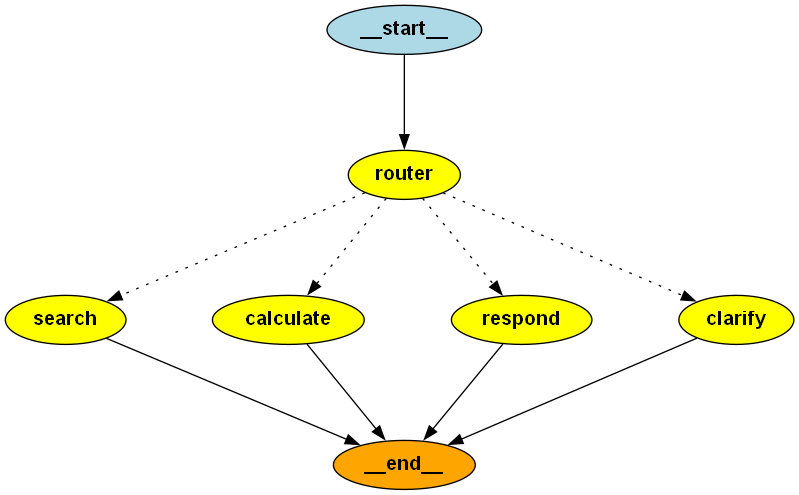


=== 测试智能路由 ===

用户: 帮我搜索一下人工智能的最新进展
LLM 决策: search
🔍 执行搜索...

用户: 计算 15 * 37 等于多少
LLM 决策: calculate
🔄 执行计算...

用户: 今天天气真好
LLM 决策: respond
📣 生成回复...

用户: 那个什么...
LLM 决策: clarify
❓ 请求澄清...


In [4]:
from typing import TypedDict, Literal
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
import json

# 注意：需要先初始化 model（根据之前的代码）
# 这里假设你已经初始化了 model，如果没有，需要先初始化
# 示例：from langchain.chat_models import init_chat_model
# model = init_chat_model("Qwen/Qwen3-8B", model_provider="openai", ...)
from dotenv import load_dotenv
import os
load_dotenv()
API_KEY = os.getenv('KEY')
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)

# === 定义状态结构 ===
class AgentState(TypedDict):
    messages: list
    next_action: str

# === LLM 路由器函数 ===
def llm_router(state: AgentState) -> Literal["search", "calculate", "respond", "clarify"]:
    """LLM 决定下一步行动"""
    messages = state["messages"]
    last_message = messages[-1].content if messages else ""
    
    routing_prompt = f"""分析用户的请求，决定下一步行动：

                        用户请求：{last_message}

                        可选行动：
                        - search: 需要搜索信息
                        - calculate: 需要计算
                        - respond: 可以直接回复
                        - clarify: 需要澄清用户意图

                        只返回行动名称，不要解释。"""
    
    # 使用全局的 model 进行调用
    response = model.invoke([HumanMessage(content=routing_prompt)])
    action = response.content.strip().lower()
    
    # 验证返回值
    valid_actions = ["search", "calculate", "respond", "clarify"]
    return action if action in valid_actions else "clarify"

# === 各个节点的处理函数 ===
def search_node(state: AgentState) -> dict:
    """搜索节点"""
    print("🔍 执行搜索...")
    # 这里可以添加实际的搜索逻辑
    return {"next_action": "search"}

def calculate_node(state: AgentState) -> dict:
    """计算节点"""
    print("🔄 执行计算...")
    # 这里可以添加实际的计算逻辑
    return {"next_action": "calculate"}

def respond_node(state: AgentState) -> dict:
    """回复节点"""
    print("📣 生成回复...")
    # 这里可以添加实际的回复生成逻辑
    return {"next_action": "respond"}

def clarify_node(state: AgentState) -> dict:
    """澄清节点"""
    print("❓ 请求澄清...")
    # 这里可以添加实际的澄清逻辑
    return {"next_action": "clarify"}

# === 显示图结构的函数 ===
def display_graph(app):
    """渲染并展示 LangGraph 应用的结构图"""
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

# === 构建 LangGraph 工作流 ===
def build_agent_graph():
    """构建智能代理的状态图"""
    # 创建状态图
    workflow = StateGraph(AgentState)
    
    # 添加节点
    workflow.add_node("router", llm_router)
    workflow.add_node("search", search_node)
    workflow.add_node("calculate", calculate_node)
    workflow.add_node("respond", respond_node)
    workflow.add_node("clarify", clarify_node)
    
    # 添加边
    workflow.add_edge(START, "router")
    
    # 添加条件边（从路由器到各个处理节点）
    workflow.add_conditional_edges(
        "router",
        lambda state: state["next_action"] if "next_action" in state else "clarify",
        {
            "search": "search",
            "calculate": "calculate", 
            "respond": "respond",
            "clarify": "clarify"
        }
    )
    
    # 从各个处理节点连接到结束
    for node in ["search", "calculate", "respond", "clarify"]:
        workflow.add_edge(node, END)
    
    # 编译图
    app = workflow.compile()
    return app

# === 主程序 ===
if __name__ == "__main__":
    # 注意：这里需要先初始化 model
    # 示例初始化（根据之前的代码）：
    from langchain.chat_models import init_chat_model
        
    # 构建并显示图
    app = build_agent_graph()
    display_graph(app)
    
    # 测试不同场景
    print("\n=== 测试智能路由 ===")
    
    test_queries = [
        "帮我搜索一下人工智能的最新进展",
        "计算 15 * 37 等于多少",
        "今天天气真好",
        "那个什么..."
    ]
    
    for query in test_queries:
        print(f"\n用户: {query}")
        
        # 创建初始状态
        initial_state = {
            "messages": [HumanMessage(content=query)],
            "next_action": ""
        }
        
        # 执行路由决策
        action = llm_router(initial_state)
        print(f"LLM 决策: {action}")
        
        # 执行相应的节点（模拟）
        state_copy = initial_state.copy()
        if action == "search":
            search_node(state_copy)
        elif action == "calculate":
            calculate_node(state_copy)
        elif action == "respond":
            respond_node(state_copy)
        else:
            clarify_node(state_copy)

## 1.3多级路由
先粗筛后细分:

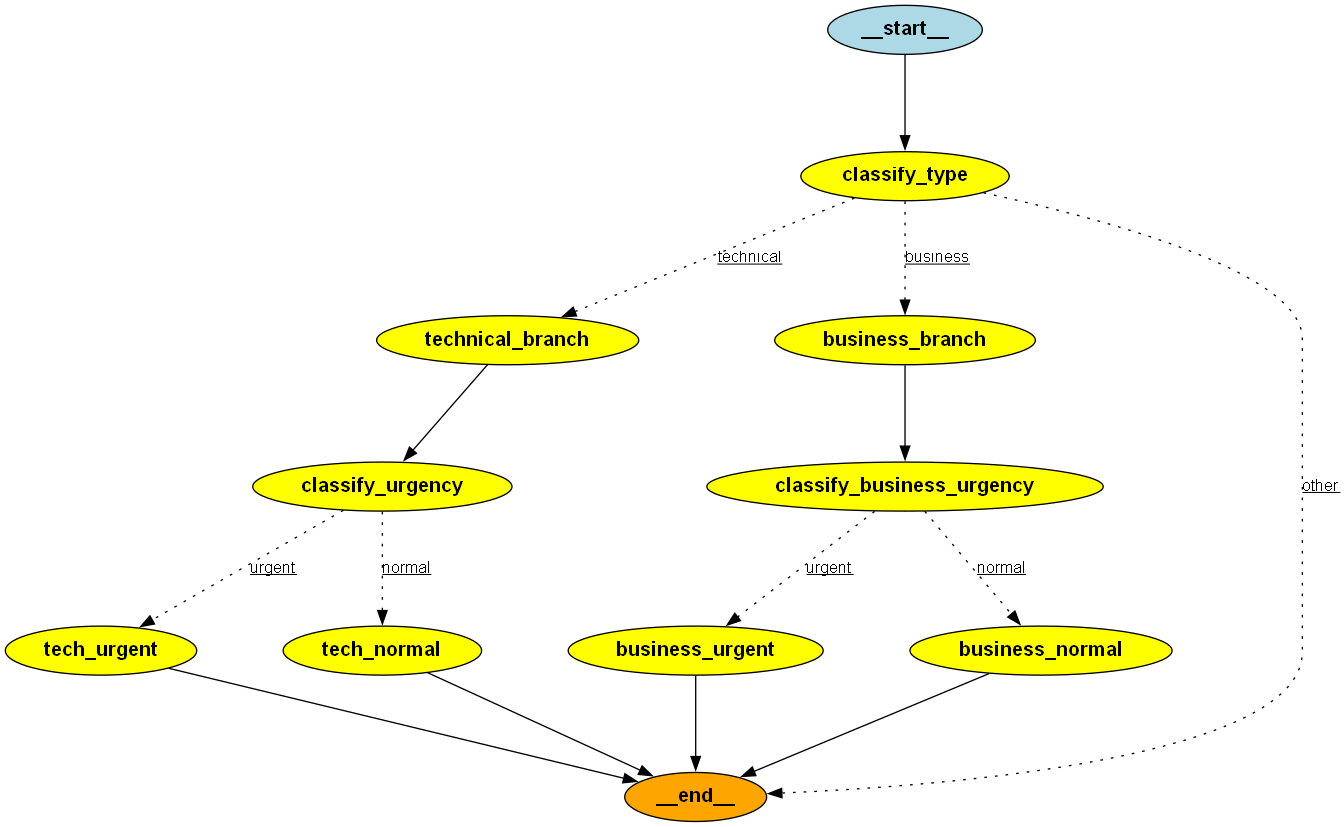


=== 测试多级路由 ===

测试 1: technical + urgent
结果: {'content_type': '', 'urgency': '', 'assigned_team': '技术紧急响应组'}

注意：当前 classify_content_type 固定返回 'technical'
     classify_urgency 固定返回 'urgent'
所以只会走 'technical' -> 'urgent' -> '技术紧急响应组' 路径


In [5]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# === 定义多级状态结构 ===
class MultiLevelState(TypedDict):  # 修复：原来是 TypeDict，应该是 TypedDict
    content_type: str
    urgency: str
    assigned_team: str

# === 第一级分类函数 ===
def classify_content_type(state: MultiLevelState) -> Literal["technical", "business", "other"]:
    """第一级：内容类型分类"""
    # 实际应用中使用 LLM
    return "technical"

# === 第二级分类函数 ===
def classify_urgency(state: MultiLevelState) -> Literal["urgent", "normal"]:
    """第二级：紧急程度分类"""
    return "urgent"

# === 处理函数 ===
def assign_technical_urgent(state: MultiLevelState) -> dict:
    return {"assigned_team": "技术紧急响应组"}

def assign_technical_normal(state: MultiLevelState) -> dict:
    return {"assigned_team": "技术支持组"}

def assign_business_urgent(state: MultiLevelState) -> dict:
    """业务分支的处理函数（示例）"""
    return {"assigned_team": "业务紧急响应组"}

def assign_business_normal(state: MultiLevelState) -> dict:
    """业务分支的处理函数（示例）"""
    return {"assigned_team": "业务支持组"}

# === 显示图结构的函数 ===
def display_graph(app):
    """渲染并展示 LangGraph 应用的结构图"""
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

# === 构建多级路由图 ===
# 创建状态图
graph = StateGraph(MultiLevelState)

# 添加第一级分类节点
graph.add_node("classify_type", lambda s: {})  # 分类节点，不修改状态
graph.add_node("technical_branch", lambda s: {})  # 技术分支入口
graph.add_node("business_branch", lambda s: {})  # 业务分支入口

# 添加第二级分类节点（technical 分支）
graph.add_node("classify_urgency", lambda s: {})  # 紧急程度分类节点
graph.add_node("tech_urgent", assign_technical_urgent)
graph.add_node("tech_normal", assign_technical_normal)

# 添加 business 分支的节点（补充完整）
graph.add_node("business_urgent", assign_business_urgent)
graph.add_node("business_normal", assign_business_normal)

# 添加边：开始 -> 第一级分类
graph.add_edge(START, "classify_type")

# 第一级条件路由
graph.add_conditional_edges(
    "classify_type",
    classify_content_type,
    {
        "technical": "technical_branch",
        "business": "business_branch",
        "other": END
    }
)

# technical 分支流程
graph.add_edge("technical_branch", "classify_urgency")

# 第二级条件路由（technical 分支）
graph.add_conditional_edges(
    "classify_urgency",
    classify_urgency,
    {
        "urgent": "tech_urgent",
        "normal": "tech_normal"
    }
)

# technical 分支结束
graph.add_edge("tech_urgent", END)
graph.add_edge("tech_normal", END)

# business 分支流程（补充完整）
def classify_business_urgency(state: MultiLevelState) -> Literal["urgent", "normal"]:
    """业务分支的紧急程度分类"""
    return "urgent"  # 示例返回值

graph.add_node("classify_business_urgency", lambda s: {})
graph.add_edge("business_branch", "classify_business_urgency")

graph.add_conditional_edges(
    "classify_business_urgency",
    classify_business_urgency,
    {
        "urgent": "business_urgent",
        "normal": "business_normal"
    }
)

graph.add_edge("business_urgent", END)
graph.add_edge("business_normal", END)

# 编译图
app = graph.compile()

# 显示图结构
display_graph(app)

# === 测试执行 ===
if __name__ == "__main__":
    print("\n=== 测试多级路由 ===")
    
    # 测试 technical + urgent 路径
    print("\n测试 1: technical + urgent")
    result = app.invoke({
        "content_type": "",
        "urgency": "",
        "assigned_team": ""
    })
    print(f"结果: {result}")
    
    # 手动测试不同路径（通过修改分类函数的返回值）
    print("\n注意：当前 classify_content_type 固定返回 'technical'")
    print("     classify_urgency 固定返回 'urgent'")
    print("所以只会走 'technical' -> 'urgent' -> '技术紧急响应组' 路径")

## 1.4循环模式
Agent的思考-行动循环:

思考中... (迭代 1)
🔲 执行工具...
思考中... (迭代 2)
🔲 执行工具...
思考中... (迭代 3)
🔲 执行工具...
思考中... (迭代 4)
🔲 执行工具...
思考中... (迭代 5)


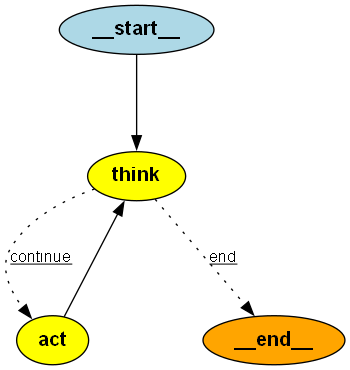

In [5]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage
from langchain.chat_models import init_chat_model

from dotenv import load_dotenv
import os
load_dotenv()
API_KEY = os.getenv('KEY')
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)

class AgentLoopState(TypedDict):
    messages: Annotated[list, add_messages]
    iterations: int
    max_iterations: int
    final_answer: str

def should_continue(state: AgentLoopState) -> Literal["continue", "end"]:
    """决定是否继续循环"""
    # 检查是否有最终答案
    if state.get("final_answer"):
        return "end"

    # 检查是否超过最大迭代次数
    if state["iterations"] >= state["max_iterations"]:
        return "end"

    return "continue"

def think_node(state: AgentLoopState) -> dict:
    """思考节点"""
    print(f"思考中... (迭代 {state['iterations'] + 1})")

    # LLM推理
    messages = state["messages"]
    response = model.invoke(messages)

    # 检查是否有答案
    if "最终答案:" in response.content:
        return {
            "final_answer": response.content,
            "iterations": state["iterations"] + 1
        }
    
    return {
        "messages": [response],
        "iterations": state["iterations"] + 1
    }

def act_node(state: AgentLoopState) -> dict:
    """行动节点（执行工具）"""
    print("🔲 执行工具...")

    # 执行工具，获取结果
    tool_result = "工具执行结果..."

    return {
        "messages": [HumanMessage(content=f"观察: {tool_result}")]
    }

# 构建循环图
loop_graph = StateGraph(AgentLoopState)
loop_graph.add_node("think", think_node)
loop_graph.add_node("act", act_node)

loop_graph.add_edge(START, "think")
loop_graph.add_conditional_edges(
    "think",
    should_continue,
    {
        "continue": "act",
        "end": END
    }
)
loop_graph.add_edge("act", "think")  # 形成循环

loop_app = loop_graph.compile()

# 运行
result = loop_app.invoke({
    "messages": [HumanMessage(content="帮我查询北京今天的天气")],
    "iterations": 0,
    "max_iterations": 5,
    "final_answer": ""
})

display_graph(loop_app)  # 需要安装相应的可视化库才能使用

# 2. Streaming: 流式输出

## 2.1 为什么需要 Streaming?

在长时间运行的任务中，用户希望看到实时进度：

- ✅ 更好的用户体验
- ✅ 实时反馈
- ✅ Token-by-Token 输出
- ✅ 监控任务进度

---

## 2.2 三种 Streaming 模式

### 模式 1: values - 完整状态

> “给我看最新的完整剧本。”

- **传输内容**：返回图的当前完整 State（状态）。
- **触发时机**：每个节点（Node）执行结束后。
- **数据格式**：包含 State 中定义的所有字段（即使某些字段没变，也会一起返回）。

**适用场景：**

- 你需要前端页面始终同步展示所有的上下文信息。
- 调试时想看每一步执行完后，整体状态变成了什么样。

**缺点**：如果 State 非常大（比如存了上百轮对话历史），每次都传输全量数据会浪费带宽。

In [ ]:
# 第1步返回：
{"messages": [HumanMessage(...)], "user_info": {...}}

# 第2步返回（包含第1步的内容）：
{"messages": [HumanMessage(...), AIMessage(...)], "user_info": {...}}

### 模式 2：updates - 状态更新

> “告诉我刚刚发生了什么变化。”

- **传输内容**：返回刚刚执行完的那个节点所产生的输出（即对 State 的修改量）。
- **触发时机**：每个节点（Node）执行结束后。
- **数据格式**：一个字典，Key 是节点名称，Value 是该节点的输出结果。

#### 适用场景：

- 构建多 Agent 系统时，想知道具体是“哪个 Agent”在干活，以及它产出了什么。
- 节省带宽，只传输变化的数据。
- 前端只需要追加显示新产生的消息，而不需要刷新整个页面。


In [ ]:
# 只有"chatbot"节点刚运行完，只返回它的更新
{"chatbot": {"messages": [AIMessage(content="Hello")]}}

### 模式 3: messages - Token 流

> “别等说完，想到一个字就告诉我一个字。”

- **传输内容**：LLM 生成的 **Token（词元）** 以及相关的元数据。
- **触发时机**：在节点执行过程中，LLM 生成内容的瞬间（实时）。
- **数据格式**：通常是 (message_chunk, metadata) 的元组。
- **核心区别**：前两种模式都要等一个节点彻底跑完代码才返回数据（Step-by-step），而 messages 是在节点内部一边跑一边返回（Token-by-token）。

#### 适用场景：

- ChatGPT 式的打字机效果：让用户感觉 AI 响应很快，不用等整个回复生成完。
- 实时反馈：在长文本生成任务中提供视觉反馈。

#### 返回示例：

```python
# 连续快速返回
("Hi", (...)), ("e1", (...)), ("10", (...)), ("1", (...))
```

LangGraph 允许你同时开启多种模式。例如，你可能既想要 updates 来知道是哪个 Agent 在说话，又想要 messages 来实现打字机效果

```python
# 同时获取更新和 Token 流
async for chunk in graph.astream(inputs, stream_mode=["updates", "messages"]):
    # chunk 可能是更新对象，也可能是 token 消息，需要根据类型处理
    print(chunk)
```    

## 2.3实战:进度条显示

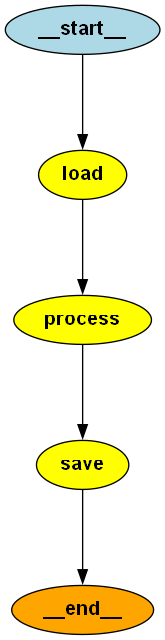


处理任务...
保存结果: [******************************] 100% (100/100)
✔ 完成!


In [6]:
import time
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END

class ProcessingState(TypedDict):
    total_items: int
    processed_items: Annotated[int, add]
    current_step: str
    progress_pct: float

def step1(state: ProcessingState) -> dict:
    """数据加载"""
    time.sleep(1)
    return {
        "processed_items": 20,
        "current_step": "数据加载",
        "progress_pct": 20.0
    }

def step2(state: ProcessingState) -> dict:
    """数据处理"""
    time.sleep(1.5)
    return {
        "processed_items": 50,
        "current_step": "数据处理",
        "progress_pct": 70.0
    }

def step3(state: ProcessingState) -> dict:
    """保存结果"""
    time.sleep(0.5)
    return {
        "processed_items": 30,
        "current_step": "保存结果",
        "progress_pct": 100.0
    }

graph = StateGraph(ProcessingState)
graph.add_node("load", step1)
graph.add_node("process", step2)
graph.add_node("save", step3)

graph.add_edge(START, "load")
graph.add_edge("load", "process")
graph.add_edge("process", "save")
graph.add_edge("save", END)

app = graph.compile()
display_graph(app)  # 需要可视化库支持

# 实时显示进度
print("\n处理任务...")
for state in app.stream({"total_items": 100, "processed_items": 0}, stream_mode="values"):
    step = state.get("current_step", "初始化")
    progress = state.get("progress_pct", 0)
    processed = state.get("processed_items", 0)

    bar_length = 30
    filled = int(bar_length * progress / 100)
    bar = "*" * filled + "-" * (bar_length - filled)

    print(f"\r{step}: [{bar}] {progress:.0f}% ({processed}/100)", end="", flush=True)

print("\n✔ 完成!")

## 2.4 Streaming + Checkpoint

In [7]:
from langgraph.checkpoint.memory import MemorySaver

# 带 checkpoint 的 streaming
checkpointer = MemorySaver()

app_with_checkpoint = graph.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "task-1"}}

print("\n=== Streaming with Checkpoint ===")
for chunk in app_with_checkpoint.stream(
    {"total_items": 100, "processed_items": 0},
    config,
    stream_mode="updates"
):
    print(f"节点更新: {chunk}")

# 查看最终 checkpoint
final_state = app_with_checkpoint.get_state(config)
print(f"\n最终状态: {final_state.values}")


=== Streaming with Checkpoint ===
节点更新: {'load': {'processed_items': 20, 'current_step': '数据加载', 'progress_pct': 20.0}}
节点更新: {'process': {'processed_items': 50, 'current_step': '数据处理', 'progress_pct': 70.0}}
节点更新: {'save': {'processed_items': 30, 'current_step': '保存结果', 'progress_pct': 100.0}}

最终状态: {'total_items': 100, 'processed_items': 100, 'current_step': '保存结果', 'progress_pct': 100.0}


# 3. Interrupts: Human-in-the-Loop

## 3.1 什么是 Interrupt?

**Interrupt** 允许图在特定节点暂停，等待外部输入（通常是人工干预）。

**使用场景：**
- ✅ 人工审核
- ✅ 确认决策
- ✅ 提供额外信息
- ✅ 修改和重试

## 3.2 使用 interrupt()

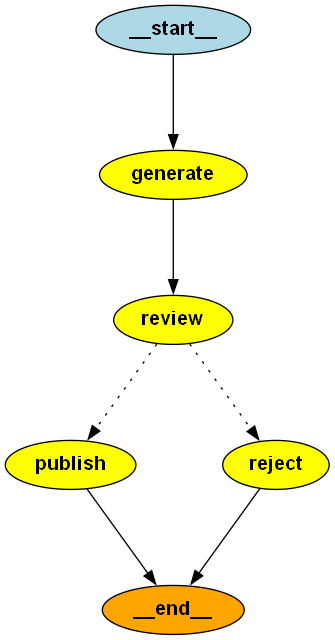


=== 第一次调用（会中断） ===
生成内容...

| 等待人工审核...
| 内容: 这是生成的内容...
状态: {'content': '这是生成的内容...', 'approved': False}

中断状态: ('review',)

=== 提供审核决策并继续 ===

| 等待人工审核...
| 内容: 这是生成的内容...
最终结果: {'content': '这是生成的内容...', 'approved': True}


In [9]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

class ReviewState(TypedDict):
    content: str
    approved: bool
    feedback: str

def generate_content(state: ReviewState) -> dict:
    """生成内容"""
    print("生成内容...")
    return {"content": "这是生成的内容..."}

def review_node(state: ReviewState) -> dict:
    """人工审核节点"""
    content = state["content"]

    print(f"\n{'='*50}")
    print(f"| 等待人工审核...")
    print(f"| 内容: {content}")

    # 暂停并等待人工输入 - 使用字典格式
    approval = interrupt({
        "question": "是否批准此内容？",
        "options": ["approve", "reject", "request_changes"]
    })

    # 根据审核结果返回
    if approval == "approve":
        return {"approved": True, "feedback": "已批准", "content": content}
    elif approval == "reject":
        return {"approved": False, "feedback": "已拒绝", "content": content}
    else:
        return {"approved": False, "feedback": "需要修改", "content": content}

def publish_node(state: ReviewState) -> dict:
    """发布内容"""
    print("📢 发布内容...")
    return {}

def reject_node(state: ReviewState) -> dict:
    """拒绝内容"""
    print("✗ 内容已拒绝")
    return {}

def should_publish(state: ReviewState) -> Literal["publish", "reject"]:
    """根据审核结果路由"""
    return "publish" if state.get("approved", False) else "reject"

# 构建图（必须使用 checkpointer）
graph = StateGraph(ReviewState)
graph.add_node("generate", generate_content)
graph.add_node("review", review_node)
graph.add_node("publish", publish_node)
graph.add_node("reject", reject_node)

graph.add_edge(START, "generate")
graph.add_edge("generate", "review")
graph.add_conditional_edges(
    "review",
    should_publish,
    {
        "publish": "publish",
        "reject": "reject"
    }
)

graph.add_edge("publish", END)
graph.add_edge("reject", END)

# 必须使用 checkpointer
checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)
display_graph(app)  # 需要可视化库支持

# 运行
config = {"configurable": {"thread_id": "review-1"}}

print("\n=== 第一次调用（会中断） ===")
result = app.invoke({"content": "", "approved": False}, config)
print(f"状态: {result}")

# 检查是否中断
state = app.get_state(config)
print(f"\n中断状态: {state.next}")    # 应该显示等待继续的节点

# 提供审核决策并继续
print("\n=== 提供审核决策并继续 ===")
app.update_state(config, {"approved": True})    # 批准
result = app.invoke(None, config)    # 继续执行
print(f"最终结果: {result}")

带选项的Interrupt:

In [ ]:
def review_with_options(state: ReviewState) -> dict:
    """带多个选项的审核"""
    content = state["content"]

    # 提供结构化的选项 - 使用字典
    decision = interrupt({
        "type": "review",
        "content": content,
        "options": [
            {"id": "approve", "label": "批准", "description": "内容无问题，批准发布"},
            {"id": "minor_edit", "label": "小修改", "description": "需要小幅修改"},
            {"id": "major_edit", "label": "大修改", "description": "需要重写"},
            {"id": "reject", "label": "拒绝", "description": "内容不合适，拒绝"}
        ]
    })
    return {"decision": decision}

# 4. Time Travel: 时间旅行

## 4.1 什么是 Time Travel?

**Time Travel** 允许你：

- 查看完整的执行历史
- 回溯到任意历史状态
- 从历史状态创建新的分支

**使用场景：**

- ✅ 调试和分析
- ✅ A/B 测试
- ✅ 审计追踪
- ✅ 撤销操作

## 4.2 查看历史

In [10]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class HistoryState(TypedDict):
    count: int
    history: list

def increment_node(state: HistoryState) -> dict:
    new_count = state.get("count", 0) + 1
    # 注意：原代码中的 .append() 会返回 None，这里修正为创建新列表
    new_history = state.get("history", []) + [f"Incremented to {new_count}"]
    return {
        "count": new_count,
        "history": new_history
    }

graph = StateGraph(HistoryState)
graph.add_node("inc1", increment_node)
graph.add_node("inc2", increment_node)
graph.add_node("inc3", increment_node)

graph.add_edge(START, "inc1")
graph.add_edge("inc1", "inc2")
graph.add_edge("inc2", "inc3")
graph.add_edge("inc3", END)

app = graph.compile(checkpointer=MemorySaver())
config = {"configurable": {"thread_id": "history-demo"}}

# 运行
result = app.invoke({"count": 0, "history": []}, config)
print(f"最终结果: {result}")

# 查看历史
print("\n=== 执行历史 ===")
history = app.get_state_history(config)

for i, checkpoint in enumerate(history):
    print(f"\nCheckpoint {i + 1}:")
    print(f"  State: {checkpoint.values}")
    print(f"  Next: {checkpoint.next}")
    print(f"  Checkpoint ID: {checkpoint.config['configurable'].get('checkpoint_id')}")

最终结果: {'count': 3, 'history': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}

=== 执行历史 ===

Checkpoint 1:
  State: {'count': 3, 'history': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}
  Next: ()
  Checkpoint ID: 1f1430c0-956b-6ec1-8003-19f6e1a52705

Checkpoint 2:
  State: {'count': 2, 'history': ['Incremented to 1', 'Incremented to 2']}
  Next: ('inc3',)
  Checkpoint ID: 1f1430c0-956b-6ec0-8002-f39f59550cdf

Checkpoint 3:
  State: {'count': 1, 'history': ['Incremented to 1']}
  Next: ('inc2',)
  Checkpoint ID: 1f1430c0-9568-6156-8001-abe3e69e71a8

Checkpoint 4:
  State: {'count': 0, 'history': []}
  Next: ('inc1',)
  Checkpoint ID: 1f1430c0-9565-6806-8000-8f4c3164acbf

Checkpoint 5:
  State: {}
  Next: ('__start__',)
  Checkpoint ID: 1f1430c0-9561-6c33-bfff-5ce2bfc9a5e0


## 4.3回溯到历史状态

In [11]:
# 获取历史中的某个 checkpoint
history_list = list(app.get_state_history(config))

# 选择第 2 个 checkpoint (count = 1)
target_checkpoint = history_list[-3]    # 倒数第三个

print(f"\n回溯到: {target_checkpoint.values}")

# 从这个 checkpoint 继续执行（会创建新分支）
new_config = {
    "configurable": {
        "thread_id": "history-demo",
        "checkpoint_id": target_checkpoint.config["configurable"]["checkpoint_id"]
    }
}

# 继续执行
result = app.invoke(None, new_config)
print(f"从历史继续的结果: {result}")


回溯到: {'count': 1, 'history': ['Incremented to 1']}
从历史继续的结果: {'count': 3, 'history': ['Incremented to 1', 'Incremented to 2', 'Incremented to 3']}


# 5.综合实战:交互式内容审核工作流
现在让我们构建一个完整的交互式内容审核系统，整合所有特性:


交互式内容审核工作流演示


📊 工作流程图结构:
------------------------------------------------------------


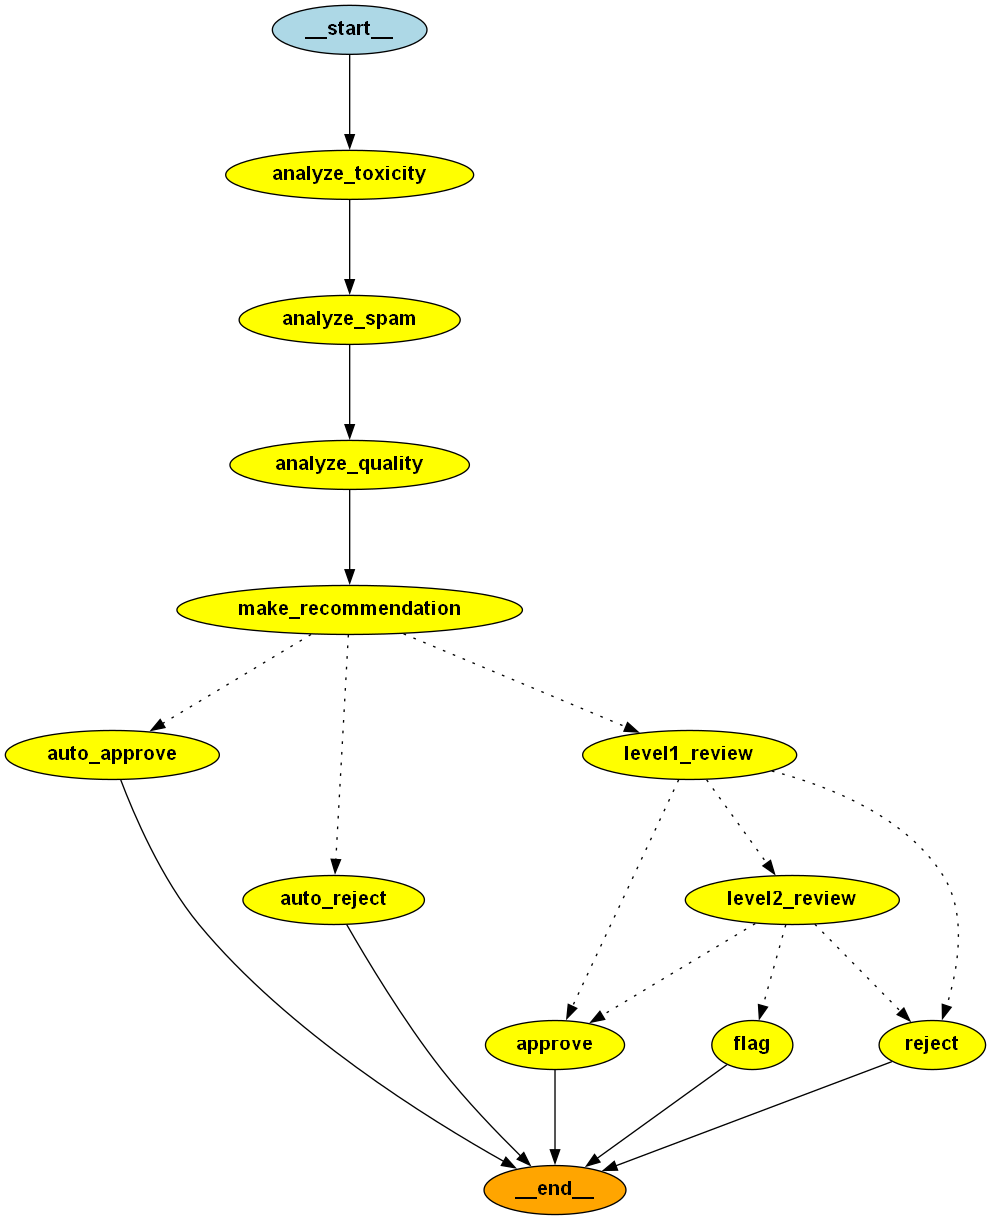

✅ 图结构渲染成功（Graphviz）

📝 待审核内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。

🚀 开始审核流程...

🍂 分析毒性...
   分析毒性完成
📈 分析垃圾信息...
   分析垃圾信息完成
⭐ 分析内容质量...
   分析质量完成
🤖 生成 AI 建议...
   建议: human_review
🤖 AI 建议: human_review

☑️ 一级审核
内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。
毒性分数: 0.00
垃圾分数: 0.00
质量分数: 0.28

📊 当前状态:
   下一节点: ('level1_review',)
   审核级别: 0

🔍 模拟审核员决策: escalate（提交二级审核）

▶️  继续执行...


☑️ 二级审核（高级）
内容: 这是一条需要审核的用户评论。内容质量较好，没有明显问题。
一级审核决策: escalate

🔍 模拟二级审核决策: approve（批准）

▶️  继续执行...

✅ 内容已批准
   批准完成

✅ 审核完成
------------------------------------------------------------
最终决策: approved
审核时间: 2026-04-28 22:43:41
审核流程: ['批准完成']

📈 执行历史
------------------------------------------------------------
共 9 个检查点

Checkpoint 1:
   决策: approved
   最后步骤: 批准完成

Checkpoint 2:
   决策: 
   最后步骤: AI 建议: human_review

Checkpoint 3:
   决策: 
   最后步骤: AI 建议: human_review

Checkpoint 4:
   决策: 
   最后步骤: AI 建议: human_review

🎉 演示完成


In [13]:
"""
交互式内容审核工作流 - 完整版
功能：自动内容分析 + 流式输出 + 多级人工审核(Interrupts) + 历史追溯 + 图可视化
"""

import time
import sqlite3
from typing import TypedDict, Annotated, Literal, Dict, Any, List
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import interrupt
from IPython.display import display, Image


def display_graph(app, xray=True):
    """可视化图结构"""
    try:
        # 尝试使用 Graphviz 渲染
        graph_image = app.get_graph(xray=xray).draw_png()
        display(Image(graph_image))
        print("✅ 图结构渲染成功（Graphviz）")
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print("=" * 60)
        print(app.get_graph(xray=xray).draw_mermaid())
        print("=" * 60)


# ============================================================
# State 定义
# ============================================================

class ReviewState(TypedDict):
    """审核状态定义"""
    # 内容信息
    content_id: str
    content: str
    content_type: str  # "article", "comment", "post"

    # 分析结果
    toxicity_score: float
    spam_score: float
    quality_score: float
    ai_recommendation: str

    # 审核流程
    review_level: int
    reviewer_decisions: List[Dict[str, Any]]
    final_decision: str  # "approved", "rejected", "flagged"

    # 元数据
    processing_steps: List[str]
    created_at: str
    reviewed_at: str


# ============================================================
# 模拟 AI 分析节点（可替换为真实 LLM）
# ============================================================

def analyze_toxicity(state: ReviewState) -> dict:
    """分析毒性"""
    print("🍂 分析毒性...")
    time.sleep(0.5)

    content = state["content"]

    # 模拟分析逻辑
    toxic_keywords = ["恨", "骂", "死", "滚", "垃圾"]
    score = sum(1 for kw in toxic_keywords if kw in content) / len(toxic_keywords)

    return {
        "toxicity_score": min(score, 1.0),
        "processing_steps": ["分析毒性完成"]
    }


def analyze_spam(state: ReviewState) -> dict:
    """分析垃圾信息"""
    print("📈 分析垃圾信息...")
    time.sleep(0.5)

    content = state["content"]

    # 模拟分析逻辑
    spam_keywords = ["广告", "加微信", "赚钱", "点击链接"]
    score = sum(1 for kw in spam_keywords if kw in content) / len(spam_keywords)

    return {
        "spam_score": min(score, 1.0),
        "processing_steps": ["分析垃圾信息完成"]
    }


def analyze_quality(state: ReviewState) -> dict:
    """分析质量"""
    print("⭐ 分析内容质量...")
    time.sleep(0.5)

    content = state["content"]

    # 模拟分析逻辑
    quality_score = min(len(content) / 100, 1.0)

    return {
        "quality_score": quality_score,
        "processing_steps": ["分析质量完成"]
    }


def make_ai_recommendation(state: ReviewState) -> dict:
    """AI 综合建议"""
    print("🤖 生成 AI 建议...")

    toxicity = state["toxicity_score"]
    spam = state["spam_score"]
    quality = state["quality_score"]

    # 规则基于的建议
    if toxicity > 0.7 or spam > 0.7:
        recommendation = "auto_reject"
    elif toxicity < 0.3 and spam < 0.3 and quality > 0.6:
        recommendation = "auto_approve"
    else:
        recommendation = "human_review"

    print(f"   建议: {recommendation}")

    return {
        "ai_recommendation": recommendation,
        "processing_steps": [f"AI 建议: {recommendation}"]
    }


# ============================================================
# 自动决策节点
# ============================================================

def auto_approve_node(state: ReviewState) -> dict:
    """自动批准节点"""
    print("✅ 自动批准内容")
    return {
        "final_decision": "approved",
        "reviewed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "processing_steps": ["自动批准完成"]
    }


def auto_reject_node(state: ReviewState) -> dict:
    """自动拒绝节点"""
    print("❌ 自动拒绝内容")
    return {
        "final_decision": "rejected",
        "reviewed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "processing_steps": ["自动拒绝完成"]
    }


# ============================================================
# 人工审核节点（使用 interrupt）
# ============================================================

def level1_review_node(state: ReviewState) -> dict:
    """一级审核（Interrupt）"""
    print("\n" + "=" * 60)
    print("☑️ 一级审核")
    print("=" * 60)
    print(f"内容: {state['content']}")
    print(f"毒性分数: {state.get('toxicity_score', 0):.2f}")
    print(f"垃圾分数: {state.get('spam_score', 0):.2f}")
    print(f"质量分数: {state.get('quality_score', 0):.2f}")
    print("=" * 60)

    # 中断，等待审核决策
    decision = interrupt({
        "type": "level1_review",
        "content": state["content"],
        "scores": {
            "toxicity": state.get("toxicity_score", 0),
            "spam": state.get("spam_score", 0),
            "quality": state.get("quality_score", 0)
        },
        "options": ["approve", "escalate", "reject"]
    })

    print(f"   决策: {decision}")

    # 获取现有决策列表
    existing_decisions = state.get("reviewer_decisions", [])
    
    return {
        "review_level": 1,
        "reviewer_decisions": existing_decisions + [{
            "level": 1,
            "decision": decision,
            "timestamp": time.time()
        }],
        "processing_steps": [f"一级审核完成，决策: {decision}"]
    }


def level2_review_node(state: ReviewState) -> dict:
    """二级审核（高级）"""
    print("\n" + "=" * 60)
    print("☑️ 二级审核（高级）")
    print("=" * 60)
    print(f"内容: {state['content']}")
    
    decisions = state.get("reviewer_decisions", [])
    if decisions:
        print(f"一级审核决策: {decisions[-1].get('decision', 'unknown')}")
    print("=" * 60)

    # 中断，等待审核决策
    decision = interrupt({
        "type": "level2_review",
        "content": state["content"],
        "previous_decisions": decisions,
        "options": ["approve", "reject", "flag"]
    })

    print(f"   决策: {decision}")

    existing_decisions = state.get("reviewer_decisions", [])
    
    return {
        "review_level": 2,
        "reviewer_decisions": existing_decisions + [{
            "level": 2,
            "decision": decision,
            "timestamp": time.time()
        }],
        "processing_steps": [f"二级审核完成，决策: {decision}"]
    }


def approve_node(state: ReviewState) -> dict:
    """批准节点"""
    print("✅ 内容已批准")
    return {
        "final_decision": "approved",
        "reviewed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "processing_steps": ["批准完成"]
    }


def reject_node(state: ReviewState) -> dict:
    """拒绝节点"""
    print("❌ 内容已拒绝")
    return {
        "final_decision": "rejected",
        "reviewed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "processing_steps": ["拒绝完成"]
    }


def flag_node(state: ReviewState) -> dict:
    """标记节点"""
    print("⚠️ 内容已标记，需要进一步审查")
    return {
        "final_decision": "flagged",
        "reviewed_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "processing_steps": ["标记完成"]
    }


# ============================================================
# 路由函数
# ============================================================

def route_by_ai_recommendation(state: ReviewState) -> Literal["auto_approve", "auto_reject", "level1_review"]:
    """根据 AI 建议路由"""
    recommendation = state.get("ai_recommendation", "human_review")
    
    if recommendation == "auto_approve":
        return "auto_approve"
    elif recommendation == "auto_reject":
        return "auto_reject"
    else:
        return "level1_review"


def route_after_level1(state: ReviewState) -> Literal["approve", "level2_review", "reject"]:
    """一级审核后路由"""
    decisions = state.get("reviewer_decisions", [])
    
    if not decisions:
        return "level2_review"

    last_decision = decisions[-1].get("decision", "reject")

    if last_decision == "approve":
        return "approve"
    elif last_decision == "escalate":
        return "level2_review"
    else:  # reject
        return "reject"


def route_after_level2(state: ReviewState) -> Literal["approve", "reject", "flag"]:
    """二级审核后路由"""
    decisions = state.get("reviewer_decisions", [])
    
    if not decisions:
        return "flag"

    last_decision = decisions[-1].get("decision", "reject")

    if last_decision == "approve":
        return "approve"
    elif last_decision == "flag":
        return "flag"
    else:  # reject
        return "reject"


# ============================================================
# 构建图（修正版 - 避免节点名与状态字段名冲突）
# ============================================================

def create_review_workflow():
    """创建审核工作流图"""
    workflow = StateGraph(ReviewState)

    # 添加分析节点
    workflow.add_node("analyze_toxicity", analyze_toxicity)
    workflow.add_node("analyze_spam", analyze_spam)
    workflow.add_node("analyze_quality", analyze_quality)
    # 关键修改：节点名从 "ai_recommendation" 改为 "make_recommendation"
    workflow.add_node("make_recommendation", make_ai_recommendation)

    # 添加决策节点
    workflow.add_node("auto_approve", auto_approve_node)
    workflow.add_node("auto_reject", auto_reject_node)
    workflow.add_node("approve", approve_node)
    workflow.add_node("reject", reject_node)
    workflow.add_node("flag", flag_node)

    # 添加审核节点
    workflow.add_node("level1_review", level1_review_node)
    workflow.add_node("level2_review", level2_review_node)

    # 添加边
    workflow.add_edge(START, "analyze_toxicity")
    workflow.add_edge("analyze_toxicity", "analyze_spam")
    workflow.add_edge("analyze_spam", "analyze_quality")
    workflow.add_edge("analyze_quality", "make_recommendation")

    # 条件边：根据 AI 建议路由
    workflow.add_conditional_edges(
        "make_recommendation",
        route_by_ai_recommendation,
        {
            "auto_approve": "auto_approve",
            "auto_reject": "auto_reject",
            "level1_review": "level1_review"
        }
    )

    # 条件边：一级审核后路由
    workflow.add_conditional_edges(
        "level1_review",
        route_after_level1,
        {
            "approve": "approve",
            "level2_review": "level2_review",
            "reject": "reject"
        }
    )

    # 条件边：二级审核后路由
    workflow.add_conditional_edges(
        "level2_review",
        route_after_level2,
        {
            "approve": "approve",
            "reject": "reject",
            "flag": "flag"
        }
    )

    # 所有终点流向 END
    for node in ["auto_approve", "auto_reject", "approve", "reject", "flag"]:
        workflow.add_edge(node, END)

    return workflow


# ============================================================
# 运行演示
# ============================================================

def run_review_demo(with_visualization=True):
    """运行审核演示"""
    print("\n" + "=" * 60)
    print("交互式内容审核工作流演示")
    print("=" * 60 + "\n")

    # 测试内容
    test_content = "这是一条需要审核的用户评论。内容质量较好，没有明显问题。"

    # 创建 SQLite checkpointer
    conn = sqlite3.connect("content_review.db", check_same_thread=False)
    checkpointer = SqliteSaver(conn)

    # 创建工作流并编译
    workflow = create_review_workflow()
    review_app = workflow.compile(checkpointer=checkpointer)

    # 可视化图结构
    if with_visualization:
        print("\n📊 工作流程图结构:")
        print("-" * 60)
        display_graph(review_app, xray=True)

    # 配置
    config = {"configurable": {"thread_id": "review-001"}}

    # 初始状态
    initial_state = {
        "content_id": "content-001",
        "content": test_content,
        "content_type": "comment",
        "toxicity_score": 0.0,
        "spam_score": 0.0,
        "quality_score": 0.0,
        "ai_recommendation": "",
        "review_level": 0,
        "reviewer_decisions": [],
        "final_decision": "",
        "processing_steps": [],
        "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "reviewed_at": ""
    }

    print(f"\n📝 待审核内容: {test_content}\n")
    print("🚀 开始审核流程...\n")

    try:
        # 流式运行
        for chunk in review_app.stream(initial_state, config, stream_mode="updates"):
            for node_name, update in chunk.items():
                if node_name in ["analyze_toxicity", "analyze_spam", "analyze_quality"]:
                    if "processing_steps" in update and update["processing_steps"]:
                        print(f"   {update['processing_steps'][-1]}")
                elif node_name == "make_recommendation":
                    if update.get("ai_recommendation"):
                        print(f"🤖 AI 建议: {update['ai_recommendation']}")
                elif node_name in ["auto_approve", "auto_reject", "approve", "reject", "flag"]:
                    if "processing_steps" in update and update["processing_steps"]:
                        print(f"   {update['processing_steps'][-1]}")
                elif node_name in ["level1_review", "level2_review"]:
                    pass  # interrupt 会暂停，不在这里显示

    except Exception as e:
        print(f"\n⏸️  工作流已中断，等待人工审核...")
        print(f"   中断信息: {e}")

    # 检查状态
    state = review_app.get_state(config)
    print(f"\n📊 当前状态:")
    print(f"   下一节点: {state.next}")
    print(f"   审核级别: {state.values.get('review_level', 0)}")

    # 模拟一级审核决策
    if state.next and "level1_review" in str(state.next):
        print("\n🔍 模拟审核员决策: escalate（提交二级审核）")

        # 更新状态，恢复执行
        review_app.update_state(
            config,
            {
                "reviewer_decisions": [{
                    "level": 1,
                    "decision": "escalate",
                    "timestamp": time.time()
                }]
            },
            as_node="level1_review"
        )

        # 继续执行
        print("\n▶️  继续执行...\n")
        try:
            for chunk in review_app.stream(None, config, stream_mode="updates"):
                for node_name, update in chunk.items():
                    if node_name == "level2_review":
                        print("   📋 进入二级审核")
                    elif node_name in ["approve", "reject", "flag"]:
                        if "processing_steps" in update and update["processing_steps"]:
                            print(f"   {update['processing_steps'][-1]}")
        except Exception as e:
            print(f"\n⏸️  再次中断，等待二级审核: {e}")

    # 检查二级审核状态
    state = review_app.get_state(config)
    if state.next and "level2_review" in str(state.next):
        print("\n🔍 模拟二级审核决策: approve（批准）")

        # 更新二级审核决策
        review_app.update_state(
            config,
            {
                "reviewer_decisions": [{
                    "level": 2,
                    "decision": "approve",
                    "timestamp": time.time()
                }]
            },
            as_node="level2_review"
        )

        # 继续执行
        print("\n▶️  继续执行...\n")
        for chunk in review_app.stream(None, config, stream_mode="updates"):
            for node_name, update in chunk.items():
                if node_name in ["approve", "reject", "flag"]:
                    if "processing_steps" in update and update["processing_steps"]:
                        print(f"   {update['processing_steps'][-1]}")

    # 最终结果
    final_state = review_app.get_state(config)
    print("\n" + "=" * 60)
    print("✅ 审核完成")
    print("-" * 60)
    print(f"最终决策: {final_state.values.get('final_decision', 'unknown')}")
    print(f"审核时间: {final_state.values.get('reviewed_at', 'N/A')}")
    print(f"审核流程: {final_state.values.get('processing_steps', [])}")
    print("=" * 60)

    # 查看历史
    print("\n📈 执行历史")
    print("-" * 60)
    history = list(review_app.get_state_history(config))
    print(f"共 {len(history)} 个检查点")

    for i, checkpoint in enumerate(history[:4]):
        print(f"\nCheckpoint {i + 1}:")
        print(f"   决策: {checkpoint.values.get('final_decision', '进行中')}")
        steps = checkpoint.values.get("processing_steps", [])
        if steps:
            print(f"   最后步骤: {steps[-1]}")
    
    print("\n" + "=" * 60)
    print("🎉 演示完成")
    print("=" * 60)


# ============================================================
# 单独的可视化函数（用于展示图而不运行完整流程）
# ============================================================

def visualize_only():
    """仅可视化图结构，不运行流程"""
    print("\n" + "=" * 60)
    print("工作流程图可视化")
    print("=" * 60)

    workflow = create_review_workflow()
    
    # 使用内存 checkpointer 编译
    from langgraph.checkpoint.memory import MemorySaver
    app = workflow.compile(checkpointer=MemorySaver())
    
    print("\n📊 图结构（带 xray 模式，显示条件边详情）:")
    display_graph(app, xray=True)
    
    print("\n📊 图结构（普通模式）:")
    display_graph(app, xray=False)


# ============================================================
# 主程序
# ============================================================

if __name__ == "__main__":
    import sys
    
    # 如果命令行参数包含 --visualize-only，则只显示图
    if len(sys.argv) > 1 and sys.argv[1] == "--visualize-only":
        visualize_only()
    else:
        # 运行完整演示（包含可视化）
        run_review_demo(with_visualization=True)